# Plot GAM results

The GAM method is described in this paper:

Keizer, I., Le Bars, D., de Valk, C., Jüling, A., van de Wal, R., and Drijfhout, S.: The acceleration of sea-level rise along the coast of the Netherlands started in the 1960s, Ocean Science, 19, 991–1007, https://doi.org/10.5194/os-19-991-2023, 2023.

The code is developped here:
https://github.com/KNMI-sealevel/NetherlandsSeaLevelAcceleration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = "../../data/knmi/gam/"
fig_dir = "../../rapportage/slm2026/images/" 

In [3]:
# Choice of stations
selection_dict = {'all': ['Maassluis', 'Vlissingen', 'Hoek van Holland', 'Den Helder', 'Delfzijl', 'Harlingen', 'IJmuiden', 'West-Terschelling'],
                  'main': ['Vlissingen', 'Hoek van Holland', 'Den Helder', 'Delfzijl', 'Harlingen', 'IJmuiden'],
                  'west': ['Maassluis', 'Vlissingen', 'Hoek van Holland', 'Den Helder', 'IJmuiden'],
                  'wadden': ['Delfzijl', 'Harlingen', 'West-Terschelling'],
                  }

# Number of bootstrap samples realized
bootsize = 1000 # Choose from 100, 1000, 10000

# Choice of statistical model
model = 'NearestPointAverage2'

# Panels name for figures
panels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

In [4]:
def read_rates_ser(station, bootsize):
    '''Read rates and standard errors'''
    
    rates_q_tgstations = []
    ser_tgstations = []
    
    for station in stations:
        output_dir = f'{data_dir}{station}/{bootsize}'
        rates_q_tgstations.append(pd.read_csv(f'{output_dir}/rates_quantiles_{model}.csv', index_col = 'time'))
        rates_tgstations = pd.read_csv(f'{output_dir}/rates_{model}.csv', index_col = 'time')
        ser_tgstations.append(rates_tgstations.std(axis=1))

    return rates_q_tgstations, ser_tgstations

## Plot rates and standard error in rate estimation: Full coast

In [5]:
rates_q_na_all = pd.read_csv(f'{data_dir}/Netherlands/{bootsize}/rates_quantiles_{model}.csv', index_col = 'time')
rates_q_na_noD = pd.read_csv(f'{data_dir}/NetherlandsNoDelfzijl/{bootsize}/rates_quantiles_{model}.csv', index_col = 'time')

In [6]:
short_names = ['$\\it{TrNtW}$ 6 main stations','$\\it{TrNtW}$ no Delfzijl']
colors = ['tab:orange', 'tab:red']

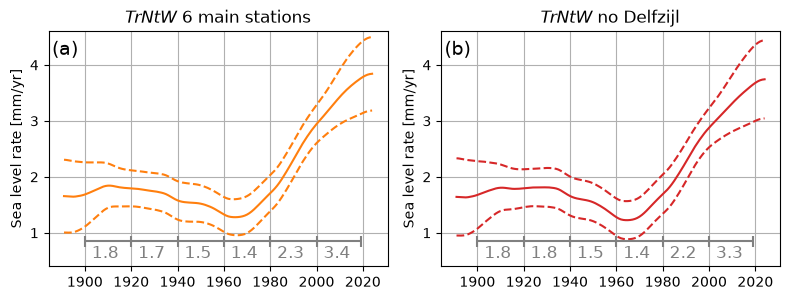

In [18]:
list_st = [1900, 1920, 1940, 1960, 1980, 2000]

fig, ax = plt.subplots(1, 2, figsize=(8,3.1))

for idx, res in enumerate([rates_q_na_all, rates_q_na_noD]):
    
    res['0.5'].plot(ax=ax.flat[idx], title=short_names[idx], color=colors[idx])
    res['0.05'].plot(ax=ax.flat[idx], linestyle='dashed', 
                                          color=colors[idx])
    res['0.95'].plot(ax=ax.flat[idx], linestyle='dashed', 
                                          color=colors[idx])
    
    ax.flat[idx].set_xlabel('')
    ax.flat[idx].set_ylabel('Sea level rate [mm/yr]')
    ax.flat[idx].set_ylim([0.4, 4.6])
    # ax.flat[idx].grid(True)
    ax.flat[idx].text(0.01, 0.9, panels[idx], transform=ax.flat[idx].transAxes, 
                      size=14)
    
    ax.flat[idx].hlines(y=0.85, xmin=list_st[0], xmax=list_st[5]+19, 
                        color='grey', linestyle='-')
    #ax.flat[idx].hlines(y=0.85, xmin=list_st[5], xmax=list_st[5]+19, 
    #                    color='grey', linestyle='-')
    
    for st in list_st:
        avg_rate = round(res.loc[st:st+19,'0.5'].mean(axis=0),1)
        ax.flat[idx].text(st+3, 0.55, avg_rate, size=12, color='grey')
        ax.flat[idx].vlines(x=st, ymin=0.75, ymax=0.95, color='grey', 
                            linestyle='-')
    ax.flat[idx].vlines(x=st+19, ymin=0.75, ymax=0.95, color='grey', linestyle='-')

for j in range(2):
   ax[j].set_xticks(np.arange(1900,2021,20))
   ax[j].grid(axis='x', which='major')
   ax[j].grid(axis='y', which='major')

fig.align_ylabels()
fig.tight_layout()
#plt.savefig(f'./figures/{region}/{bootsize}/RateSeaLevelTrend.pdf', dpi=150)


## Plot rates and standard error in rate estimation: Individual stations

In [19]:
stations = selection_dict['wadden'] # all, main, west, wadden
rates_q_tgstations_wa, ser_tgstations_wa = read_rates_ser(stations, bootsize)

In [20]:
stations

['Delfzijl', 'Harlingen', 'West-Terschelling']

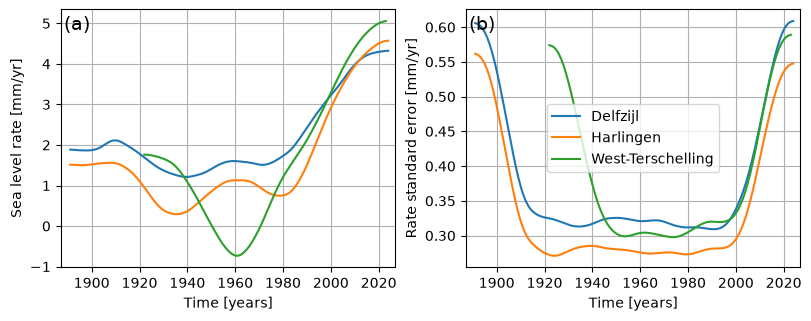

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(8,3.1), constrained_layout=True)

# Panel 1
for idx, station in enumerate(stations):
    axs[0].plot(rates_q_tgstations_wa[idx].index, rates_q_tgstations_wa[idx]['0.5'], label = station)
    
axs[0].set_xlabel('Time [years]')
axs[0].set_ylabel('Sea level rate [mm/yr]')
axs[0].grid()
axs[0].text(0.01, 0.92, panels[0], transform=axs[0].transAxes, size=14)

# Panel 2
for idx, station in enumerate(stations):
    axs[1].plot(ser_tgstations_wa[idx].index, ser_tgstations_wa[idx].values, label = station)

axs[1].set_xlabel('Time [years]')
axs[1].set_ylabel('Rate standard error [mm/yr]')
axs[1].legend()
axs[1].grid()
axs[1].text(0.01, 0.92, panels[1], transform=axs[1].transAxes, size=14)

for i in range(2):
    axs[i].set_xlim((1887,2027))


In [22]:
stations = selection_dict['west']
rates_q_tgstations_we, ser_tgstations_we = read_rates_ser(stations, bootsize)

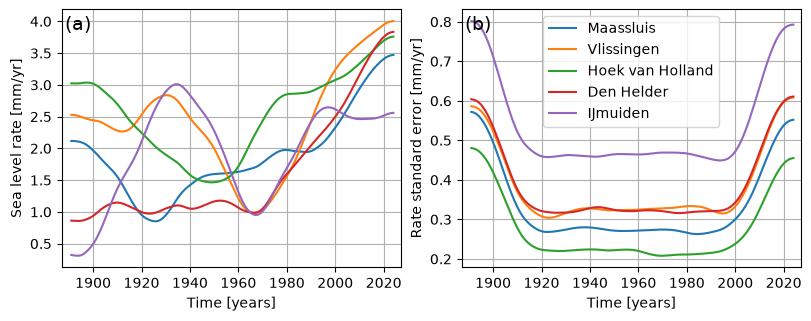

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(8,3.1), constrained_layout=True)

# Panel 1
for idx, station in enumerate(stations):
    axs[0].plot(rates_q_tgstations_we[idx].index, rates_q_tgstations_we[idx]['0.5'], label = station)
    
axs[0].set_xlabel('Time [years]')
axs[0].set_ylabel('Sea level rate [mm/yr]')
axs[0].grid()
axs[0].text(0.01, 0.92, panels[0], transform=axs[0].transAxes, size=14)

# Panel 2
for idx, station in enumerate(stations):
    axs[1].plot(ser_tgstations_we[idx].index, ser_tgstations_we[idx].values, label = station)

axs[1].set_xlabel('Time [years]')
axs[1].set_ylabel('Rate standard error [mm/yr]')
axs[1].legend()
axs[1].grid()
axs[1].text(0.01, 0.92, panels[1], transform=axs[1].transAxes, size=14)

for i in range(2):
    axs[i].set_xlim((1887,2027))

## Plot a comparison west NL and Wadden on the same figure with two panels without standard errors

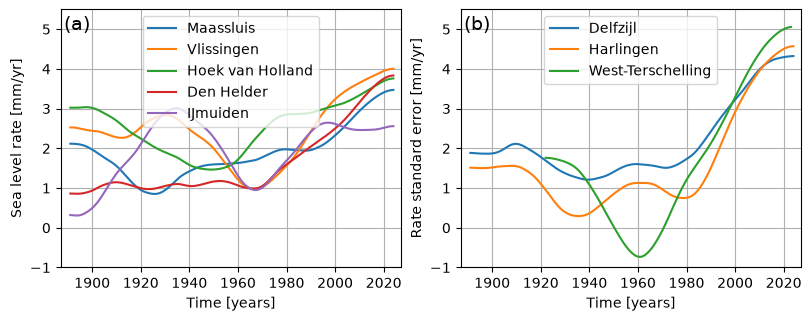

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8,3.1), constrained_layout=True)

# Panel 1
for idx, station in enumerate(selection_dict['west']):
    axs[0].plot(rates_q_tgstations_we[idx].index, rates_q_tgstations_we[idx]['0.5'], label = station)
    
axs[0].set_xlabel('Time [years]')
axs[0].set_ylabel('Sea level rate [mm/yr]')
axs[0].legend(loc='upper center')
axs[0].grid()
axs[0].text(0.01, 0.92, panels[0], transform=axs[0].transAxes, size=14)

# Panel 2
for idx, station in enumerate(selection_dict['wadden']):
    axs[1].plot(rates_q_tgstations_wa[idx].index, rates_q_tgstations_wa[idx]['0.5'], label = station)

axs[1].set_xlabel('Time [years]')
axs[1].set_ylabel('Rate standard error [mm/yr]')
axs[1].legend()
axs[1].grid()
axs[1].text(0.01, 0.92, panels[1], transform=axs[1].transAxes, size=14)

for i in range(2):
    axs[i].set_xlim((1887,2027))
    axs[i].set_ylim((-1,5.5))

#plt.savefig(f'{fig_dir}GAM_RateSeaLevel_{model}_{bootsize}_{selection}.png', dpi=300)